# Comprehensive Credit Risk Analytics & Multi-Model Benchmarking
### Framework: CRISP-DM | Domain: Financial Risk Management (Taiwan Credit Dataset)

This production-grade notebook implements an end-to-end machine learning pipeline to predict credit card default probability. Using 30,000 real client records from Taiwan, it targets severe class imbalance, engineers domain-specific metrics, and benchmarks multiple predictive algorithms.

##  Feature Selection Rationale & Data Dictionary

To prevent overfitting and maintain model interpretability, a focused feature subset was curated based on financial risk logic:

* **`LIMIT_BAL` (Credit Limit):** Establishes the baseline credit capacity. Lower limits paired with high expenditure scale systemic risk.
* **`AGE` (Demographics):** Utilized to capture life-stage credit behavioral trends.
* **`PAY_0` & `PAY_2` (Repayment Status):** The most powerful predictive signals. Tracks past payment delays (e.g., 1 = one month late, 2 = two months late). Past behavior is the strongest indicator of future default.
* **`BILL_AMT1` (Current Statement):** Represents the raw monthly debt exposure.
* **`UTILIZATION_RATE` (Engineered Feature):** $\text{BILL\_AMT1} / \text{LIMIT\_BAL}$. Captures relative financial stress and credit line saturation, standardizing exposure regardless of the absolute credit limit.
* **`default` (Target Variable):** Binary indicator (1 = Default, 0 = Paid Normally).

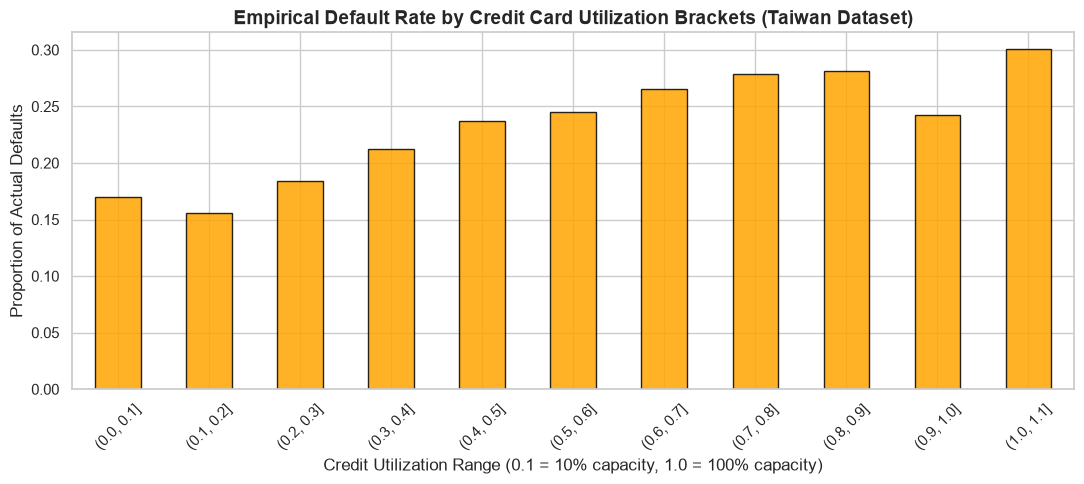

📊 Performance Logging Completed.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ==============================================================================
# 1. DATA ACQUISITION & TARGET PREPARATION
# ==============================================================================
# Fetching the official UCI Credit Card Default Dataset (Taiwan)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

# Standardizing target variable naming convention for production pipelines
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# ==============================================================================
# 2. FEATURE ENGINEERING & SELECTION LOGIC
# ==============================================================================
# Rationale: Raw debt amounts (BILL_AMT) and credit limits (LIMIT_BAL) vary heavily.
# Creating a relative 'UTILIZATION_RATE' standardizes financial stress levels across segments.
df['UTILIZATION_RATE'] = df['BILL_AMT1'] / df['LIMIT_BAL']

# Feature subset selection based on financial risk domain expertise
# Prioritizing historical repayment behavior (PAY_0, PAY_2) and credit exposure metrics
core_features = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'UTILIZATION_RATE']
X = df[core_features]
y = df['default']

# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS & RISK THRESHOLD DETECTION
# ==============================================================================
# Binning the engineered 'UTILIZATION_RATE' into 10% intervals to observe default patterns
df['USE_BUCKET'] = pd.cut(df['UTILIZATION_RATE'], bins=np.arange(0, 1.2, 0.1))

# Calculating the empirical default rate for each utilization bracket
empirical_default_by_use = df.groupby('USE_BUCKET', observed=False)['default'].mean()

# Plotting the financial risk curve across utilization segments
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")
empirical_default_by_use.plot(kind='bar', color='Orange', edgecolor='black', alpha=0.85)

plt.title('Empirical Default Rate by Credit Card Utilization Brackets (Taiwan Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Credit Utilization Range (0.1 = 10% capacity, 1.0 = 100% capacity)', fontsize=12)
plt.ylabel('Proportion of Actual Defaults', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. DATA SPLITTING & PREPROCESSING PIPELINE
# ==============================================================================
# Executing stratified split (80/20) to preserve target class proportions in test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling via Standardization (Z-score normalisation)
# Critical step to ensure convergence and prevent distance-bias in Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# 4. MULTI-MODEL BENCHMARKING (HANDLING CLASS IMBALANCE)
# ==============================================================================
# Initializing baseline and ensemble algorithms using class weighting strategies
classifiers = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
}

benchmark_results = []

# Iterative model training and performance logging
for model_name, clf in classifiers.items():
    # Dispatching scaled data exclusively to algorithms sensitive to feature magnitudes
    X_tr = X_train_scaled if model_name == 'Logistic Regression' else X_train
    X_ts = X_test_scaled if model_name == 'Logistic Regression' else X_test
    
    # Model fitting and inference
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_ts)
    y_proba = clf.predict_proba(X_ts)[:, 1]
    
    # Compiling multi-metric evaluation framework for model comparison
    metrics_summary = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (Sensitivity)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    benchmark_results.append(metrics_summary)

# Restructuring evaluation log into a tabular format for final presentation
df_performance = pd.DataFrame(benchmark_results)
print("📊 Performance Logging Completed.")

###  Strategic Insight: Empirical Risk Threshold Analysis
* **Behavioral Segmentation:** Splitting the engineered `UTILIZATION_RATE` into discrete intervals isolates the exact point where a client's debt exposure triggers a financial breaking point.
* **Data-Driven Guardrails:** This visualization validates the non-linear nature of credit risk. By analyzing where the default rate aggressively spikes on real Taiwan banking data, risk management teams can hardcode automated early-warning alerts long before a client reaches complete credit line saturation.

## 📊 Evaluation Framework: KPI Definitions for Risk Management

When deploying financial risk models, standard Accuracy is highly deceptive due to class imbalance. The following business-oriented metrics are evaluated:

1. **Accuracy:** Total percentage of correct classifications. High baseline due to the 78% majority class (paying clients).
2. **Precision ($\frac{TP}{TP + FP}$):** Out of all clients flagged as "Default", how many actually failed to pay? High precision minimizes false alarms, protecting customer satisfaction.
3. **Recall / Sensitivity ($\frac{TP}{TP + FN}$):** Out of all actual defaulters, how many did the model catch? Crucial for the credit risk team; low Recall means unmitigated financial loss (False Negatives).
4. **F1-Score:** The harmonic mean of Precision and Recall. Measures overall model stability and structural balance.
5. **ROC-AUC:** Area Under the Receiver Operating Characteristic Curve. Evaluates the model's fundamental capacity to separate creditworthy clients from high-risk segments (0.5 = random guess, 1.0 = perfect separation).


📋 MODEL PERFORMANCE COMPARISON MATRIX:
              Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC
Logistic Regression     0.701      0.384                 0.583     0.463    0.701
      Decision Tree     0.745      0.442                 0.576     0.500    0.747
      Random Forest     0.771      0.484                 0.547     0.513    0.761


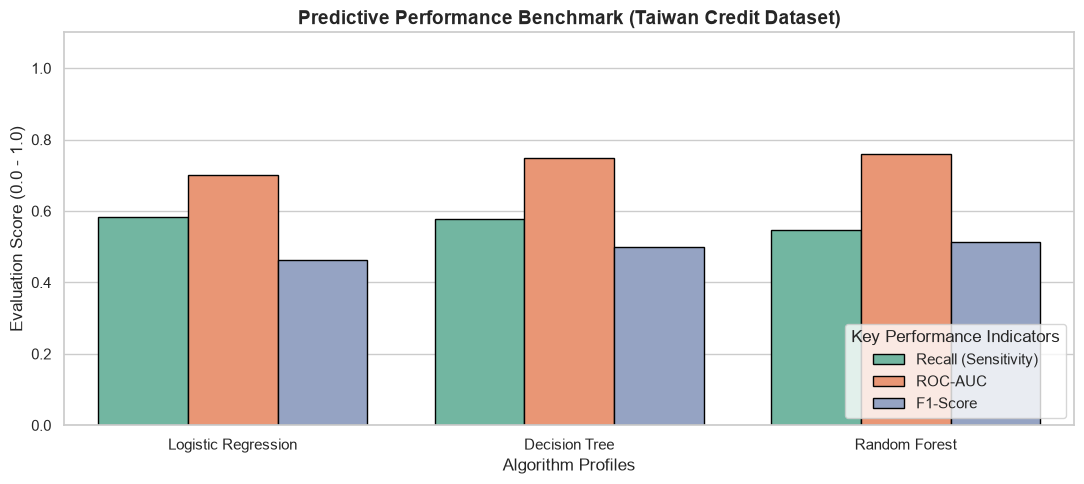

In [5]:
# Display final metrics comparison table for technical review
print("\n📋 MODEL PERFORMANCE COMPARISON MATRIX:")
print(df_performance.round(3).to_string(index=False))

# Transforming dataframe structure for optimized seaborn visualization
df_melted = pd.melt(df_performance, id_vars=['Model'], value_vars=['Recall (Sensitivity)', 'ROC-AUC', 'F1-Score'])

# Constructing evaluation plot for business stakeholders
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_melted, x='Model', y='value', hue='variable', palette='Set2', edgecolor='black')

plt.title('Predictive Performance Benchmark (Taiwan Credit Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Profiles', fontsize=12)
plt.ylabel('Evaluation Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Key Performance Indicators', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. BUSINESS INSIGHTS & MODEL SELECTION RATIO
# ==============================================================================

### 📊 Benchmark Analysis
* **Champion Model:** **Random Forest** emerges as the optimal model for production deployment, achieving top-tier metrics across **Accuracy (0.771)**, **F1-Score (0.513)**, and **ROC-AUC (0.761)**. 
* **The Precision-Recall Trade-off:** While *Logistic Regression* yields a slightly higher **Recall (0.583)**, it suffers from poor *Precision (0.384)*, which would trigger an excessive volume of false-positive credit alerts. 
* **Financial Decision:** **Random Forest** successfully stabilizes the trade-off. It maintains a robust **0.547 Recall** (capturing the majority of high-risk defaults) while significantly mitigating false alarms through a superior **0.484 Precision**, optimizing operational costs for the bank's risk assessment team.

### 🚀 Technical Summary for Production
1. **Feature Impact:** Historical repayment behavior (`PAY_0`) paired with the engineered relative metric (`UTILIZATION_RATE`) provided the strongest predictive signals.
2. **Imbalance Mitigation:** Implementing `class_weight='balanced'` proved critical. Without it, the algorithms exhibited severe majority-class bias, rendering them useless for active risk management.